In [1]:
import os
import numpy as np
import json

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [2]:
features_dir = "../features"

X_train_pca = np.load(
    os.path.join(features_dir, "X_train_pca.npy")
)

X_test_pca = np.load(
    os.path.join(features_dir, "X_test_pca.npy")
)

y_train = np.load(
    os.path.join(features_dir, "y_train.npy")
)

y_test = np.load(
    os.path.join(features_dir, "y_test.npy")
)

In [3]:
with open(
    os.path.join(features_dir, "label_map.json"),
    "r"
) as f:
    label_map = json.load(f)

classes = [
    class_name
    for class_name, label in sorted(
        label_map.items(),
        key=lambda x: int(x[1])
    )
]

print(classes)

['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [4]:
print("X_train:", X_train_pca.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test_pca.shape)
print("y_test:", y_test.shape)

X_train: (5000, 1485)
y_train: (5000,)
X_test: (1000, 1485)
y_test: (1000,)


In [5]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [7]:
param_grid = {
    "C": [0.1, 1, 10]
}
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_lr.fit(
    X_train_pca,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

In [8]:
print(
    "Best C:",
    grid_lr.best_params_["C"]
)

print(
    "Best CV Macro F1:",
    grid_lr.best_score_
)

Best C: 0.1
Best CV Macro F1: 0.6285913811351546


In [9]:
best_lr = grid_lr.best_estimator_

In [10]:
y_pred_lr = best_lr.predict(
    X_test_pca
)

In [11]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Macro Precision: {lr_precision * 100:.2f}%")
print(f"Macro Recall: {lr_recall * 100:.2f}%")
print(f"Macro F1: {lr_f1 * 100:.2f}%")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=classes,
        zero_division=0
    )
)

Accuracy: 90.90%
Macro Precision: 91.18%
Macro Recall: 91.82%
Macro F1: 91.35%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.83      0.88       254
  meningioma       0.87      0.86      0.86       306
    no_tumor       0.92      1.00      0.96       140
   pituitary       0.93      0.99      0.96       300

    accuracy                           0.91      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.91      0.91      0.91      1000



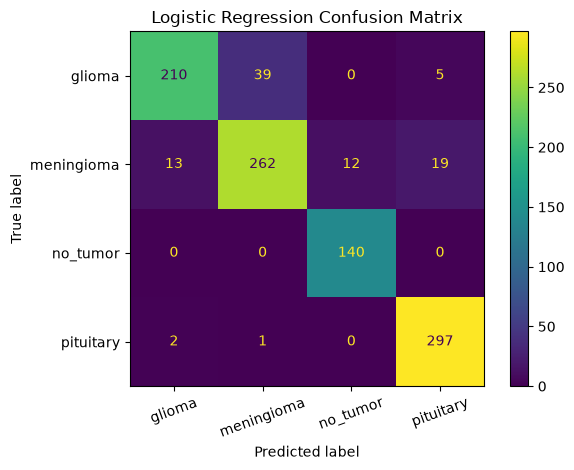

In [12]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=classes
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:
lr_results = {
    "Model": "Logistic Regression",
    "Best C": grid_lr.best_params_["C"],
    "Accuracy": lr_accuracy,
    "Macro Precision": lr_precision,
    "Macro Recall": lr_recall,
    "Macro F1": lr_f1
}

print(lr_results)

{'Model': 'Logistic Regression', 'Best C': 0.1, 'Accuracy': 0.909, 'Macro Precision': 0.9117923196615665, 'Macro Recall': 0.9182452009675262, 'Macro F1': 0.9135236690802095}


In [14]:
import joblib

joblib.dump(
    best_lr,
    "../features/logistic_regression_model.pkl"
)

['../features/logistic_regression_model.pkl']

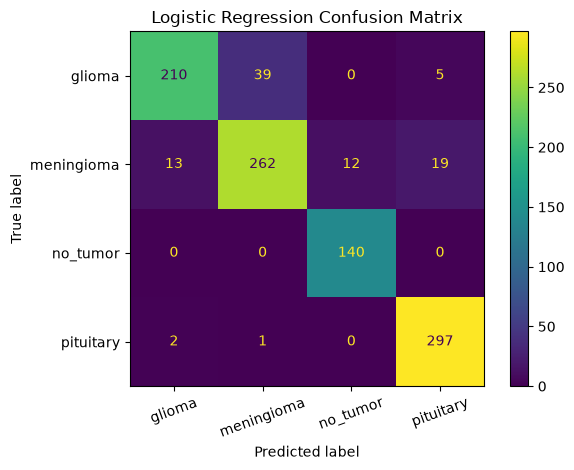

In [16]:
import os

os.makedirs("../results", exist_ok=True)

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=classes
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../results/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
import json

with open(
    "../results/logistic_regression_results.json",
    "w"
) as f:
    json.dump(
        lr_results,
        f,
        indent=4
    )

print("Logistic Regression results saved.")

Logistic Regression results saved.


In [18]:
print(lr_results)

{'Model': 'Logistic Regression', 'Best C': 0.1, 'Accuracy': 0.909, 'Macro Precision': 0.9117923196615665, 'Macro Recall': 0.9182452009675262, 'Macro F1': 0.9135236690802095}
